In [ ]:
import pandas as pd
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Train-test split & tuning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

# Feature selection
from sklearn.feature_selection import SelectKBest, chi2

# Handling class imbalance
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, VotingClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

# Evaluation
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
        roc_auc_score, confusion_matrix, classification_report
        )




**in application date we have to change objective to date time**

**we have to change all categorical data in encoding**

In [ ]:
df=pd.read_csv("/content/Loan.csv")
df.head(5)

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  int64  
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  int64  
 8   LoanDuration                20000 non-null  int64  
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

In [ ]:
df.duplicated().sum()

np.int64(0)

**Performing EDA in categorical and numericaldata(bivariate)**

In [ ]:
df["Age"].describe()

,Age
count,20000.000000
mean,39.752600
std,11.622713
min,18.000000
25%,32.000000
50%,40.000000
75%,48.000000
max,80.000000


In [ ]:
df["Age"].skew()

np.float64(0.1859639313618668)

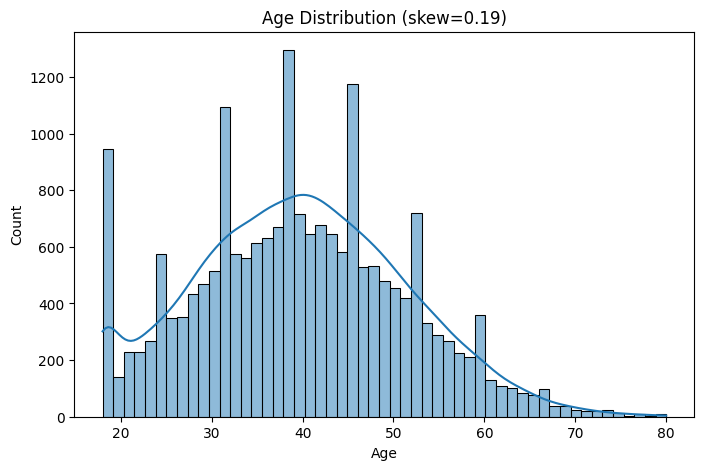

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], kde=True)
plt.title(f"Age Distribution (skew={df['Age'].skew():.2f})")
plt.show()

{'whiskers': [<matplotlib.lines.Line2D at 0x7f6c04590b30>,
 'caps': [<matplotlib.lines.Line2D at 0x7f6c045922d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f6c04591580>],
 'medians': [<matplotlib.lines.Line2D at 0x7f6c04590410>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f6c045912b0>],
 'means': []}

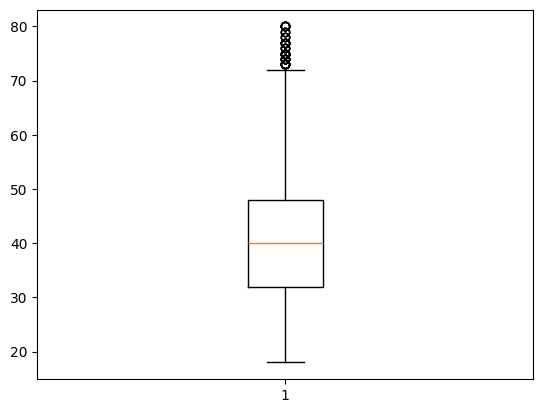

In [ ]:
plt.boxplot(df["Age"])

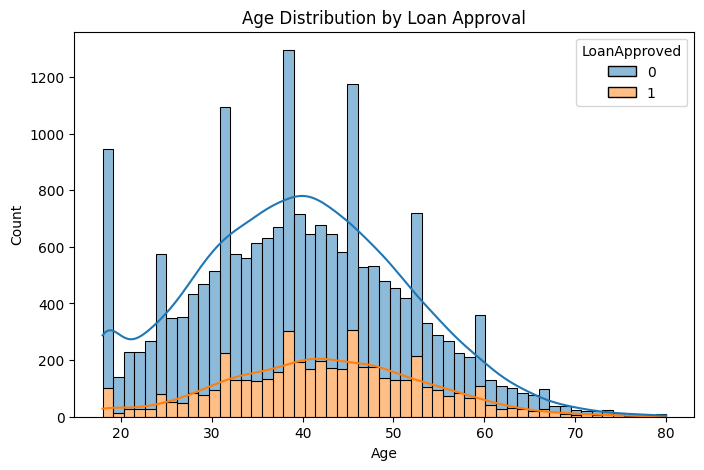

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Age', hue='LoanApproved', kde=True, multiple='stack')
plt.title("Age Distribution by Loan Approval")
plt.show()

**univariate analysis and buy various analysis on Annualincome and loan approved**

In [ ]:
df["AnnualIncome"].describe()

,AnnualIncome
count,20000.000000
mean,59161.473550
std,40350.845168
min,15000.000000
25%,31679.000000
50%,48566.000000
75%,74391.000000
max,485341.000000


In [ ]:
df.query("AnnualIncome>450000")

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
15066,2059-04-02,47,485341,620,Employed,Bachelor,25,35042,48,Widowed,...,24935.833333,0.769074,4,4581,0.220042,0.234557,1131.914177,0.056221,1,37.6


In [ ]:
df["AnnualIncome"].skew()

np.float64(2.088947958524819)

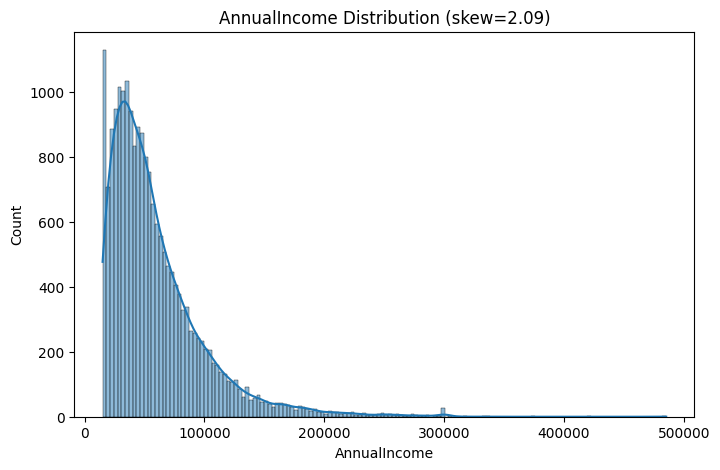

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['AnnualIncome'], kde=True)
plt.title(f"AnnualIncome Distribution (skew={df['AnnualIncome'].skew():.2f})")
plt.show()

In [ ]:
df['AnnualIncome'] = np.log1p(df['AnnualIncome'])
print(df['AnnualIncome'].skew())

0.15867184767171486


In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='AnnualIncome', hue='LoanApproved', kde=True, multiple='stack')
plt.title("AnnualIncome Distribution by Loan Approval")
plt.show()

**we have to perform univariate and buy variant analysis on credit score and loan approved both**

In [ ]:
df["CreditScore"].describe()

In [ ]:
df.query("CreditScore>=500")

In [ ]:
df["CreditScore"].skew()

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['CreditScore'], kde=True)
plt.title(f"CreditScore Distribution (skew={df['CreditScore'].skew():.2f})")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='CreditScore', hue='LoanApproved', kde=True, multiple='stack')
plt.title("CreditScore Distribution by Loan Approval")
plt.show()

**now we have to do buyvartiot and univariet analysis on EmploymentStatus and loanApproved**

In [ ]:
df['EmploymentStatus'].value_counts()

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='EmploymentStatus', hue='LoanApproved')
plt.title("Employment Status vs Loan Approved")
plt.xticks(rotation=45)
plt.show()

**now we have to perform by various and univariate analysis on education qualification on the basis of loan approved or not**

In [ ]:
df['EducationLevel'].value_counts()

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x='EducationLevel', hue='LoanApproved')
plt.title("Education level vs Loan Approved")
plt.xticks(rotation=45)
plt.show()

In [ ]:
pd.crosstab(df['EducationLevel'], df['LoanApproved'], normalize='index').plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Loan Approval Rate by Educational level")
plt.ylabel("Proportion")
plt.show()

In [ ]:
df.head(5)

**now we have to perform univariate and by various analysis on experience on and buy on loan approved**

In [ ]:
df["Experience"].describe()

In [ ]:
df[df["Experience"]==61]

In [ ]:
df["Experience"].skew()

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['Experience'], kde=True)
plt.title(f"Expierence Distribution (skew={df['Age'].skew():.2f})")
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x='Experience', hue='LoanApproved', kde=True, multiple='stack')
plt.title("Experice Distribution by Loan Approval")
plt.show()

** univariate and buyvariete analys on LoanAmount and loan approved**

In [ ]:
df["LoanAmount"].describe()

In [ ]:
df["LoanAmount"].skew()

In [ ]:
df[df["LoanAmount"]==184732]

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['LoanAmount'], kde=True)
plt.title(f"LoanAmount Distribution (skew={df['Age'].skew():.2f})")
plt.show()

In [ ]:
df['LoanAmount'] = np.log1p(df['LoanAmount'])
print(df['LoanAmount'].skew())

**Univariate and buyVariate analys on the baaes LoanDuration and LoanApproved**

In [ ]:
df["LoanDuration"].describe()

In [ ]:
df[df["LoanDuration"]==120]

In [ ]:
df["LoanDuration"].skew()

In [ ]:
df["LoanDuration"] = np.sqrt(df["LoanDuration"])
print(df["LoanDuration"].skew())

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["LoanDuration"], kde=True)
plt.title(f"LoanDuration Distribution (skew={df['LoanDuration'].skew():.2f})")
plt.show()

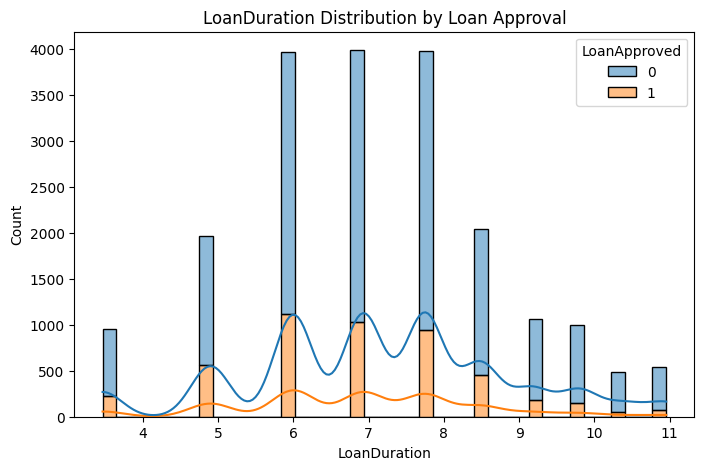

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="LoanDuration", hue="LoanApproved", kde=True, multiple='stack')
plt.title("LoanDuration Distribution by Loan Approval")
plt.show()

**Univariate and buyVariate analys on the baaes Martial Status and LoanApproved**

In [ ]:
df["MaritalStatus"].value_counts()

,count
MaritalStatus,
Married,10041
Single,6078
Divorced,2882
Widowed,999


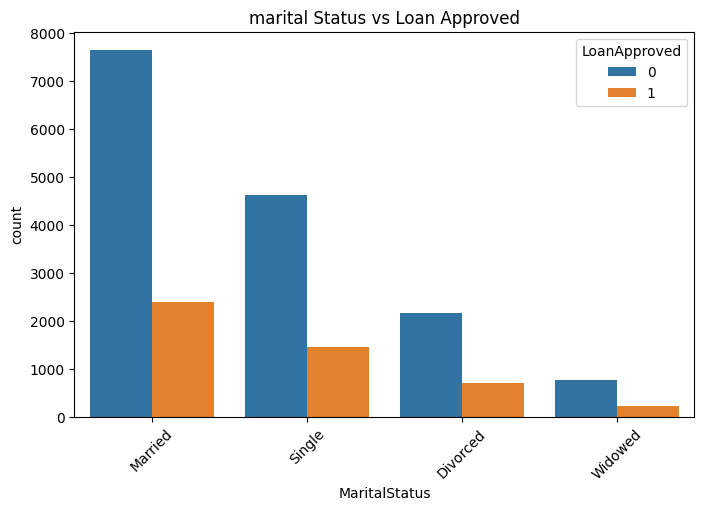

In [ ]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="MaritalStatus", hue="LoanApproved")
plt.title("marital Status vs Loan Approved")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.head(3)

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,10.595359,617,Employed,Master,22,9.484405,6.928203,Married,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,2018-01-02,38,10.589358,628,Employed,Associate,15,10.167619,6.928203,Single,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,2018-01-03,47,10.614597,570,Employed,Bachelor,26,9.777244,6.000000,Married,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0


****Univariate and buyVariate analys on the bases MonthlyIncome and LoanApproved**
**

In [ ]:
df["MonthlyIncome"].describe()

,MonthlyIncome
count,20000.000000
mean,4891.715521
std,3296.771598
min,1250.000000
25%,2629.583333
50%,4034.750000
75%,6163.000000
max,25000.000000


In [ ]:
df["MonthlyIncome"].skew()

np.float64(1.9929285551564344)

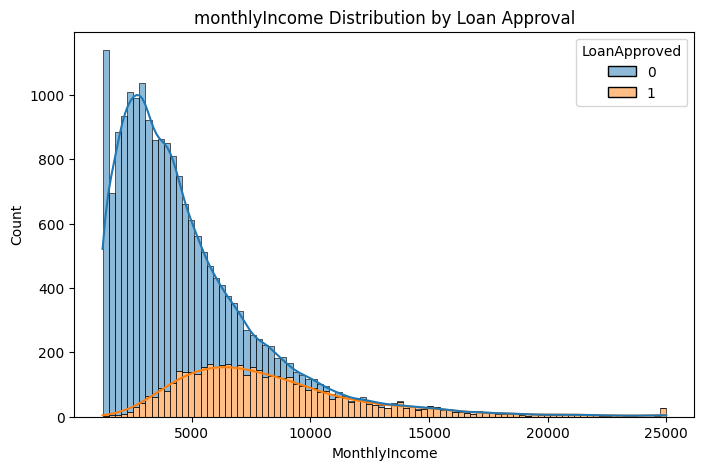

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="MonthlyIncome", hue='LoanApproved', kde=True, multiple='stack')
plt.title("monthlyIncome Distribution by Loan Approval")
plt.show()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  float64
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  float64
 8   LoanDuration                20000 non-null  float64
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

**remaining ida on numerical columns on bulk Skew check**

In [ ]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns.tolist()
skew_value=df[num_cols].skew().sort_values(ascending=False)
print(skew_value)

SavingsAccountBalance         6.060099
TotalLiabilities              5.848874
NetWorth                      5.599844
TotalAssets                   5.311326
CheckingAccountBalance        4.746142
BankruptcyHistory             4.017672
MonthlyLoanPayment            3.081845
PreviousLoanDefaults          2.665941
TotalDebtToIncomeRatio        2.574494
MonthlyIncome                 1.992929
MonthlyDebtPayments           1.653435
LoanApproved                  1.224086
NumberOfCreditInquiries       1.012065
NumberOfDependents            0.639919
CreditCardUtilizationRate     0.601131
NumberOfOpenCreditLines       0.599662
DebtToIncomeRatio             0.593858
InterestRate                  0.485491
BaseInterestRate              0.461850
JobTenure                     0.436452
Experience                    0.339981
PaymentHistory                0.213465
Age                           0.185964
AnnualIncome                  0.158672
LoanDuration                  0.017966
LoanAmount               

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ApplicationDate             20000 non-null  object 
 1   Age                         20000 non-null  int64  
 2   AnnualIncome                20000 non-null  float64
 3   CreditScore                 20000 non-null  int64  
 4   EmploymentStatus            20000 non-null  object 
 5   EducationLevel              20000 non-null  object 
 6   Experience                  20000 non-null  int64  
 7   LoanAmount                  20000 non-null  float64
 8   LoanDuration                20000 non-null  float64
 9   MaritalStatus               20000 non-null  object 
 10  NumberOfDependents          20000 non-null  int64  
 11  HomeOwnershipStatus         20000 non-null  object 
 12  MonthlyDebtPayments         20000 non-null  int64  
 13  CreditCardUtilizationRate   200

**now we have to perform univariate and by various analysis on number of dependents and loan approved**

In [ ]:
df["NumberOfDependents"].describe()

,NumberOfDependents
count,20000.000000
mean,1.517300
std,1.386325
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,5.000000


In [ ]:
df["NumberOfDependents"].skew()

np.float64(0.6399193421240162)

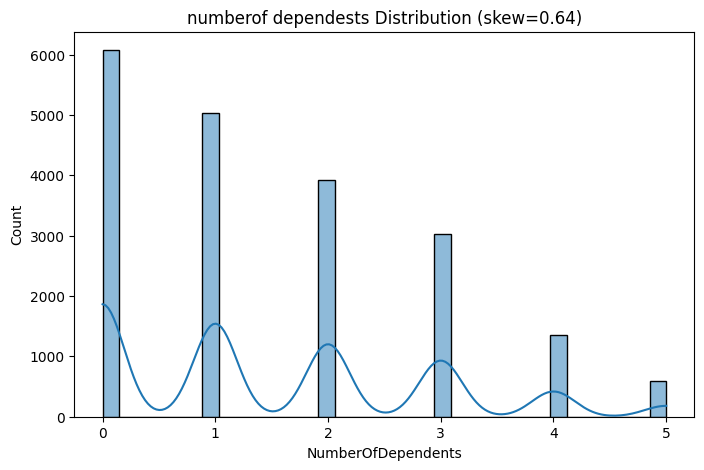

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df["NumberOfDependents"],kde=True)
plt.title(f"numberof dependests Distribution (skew={df['NumberOfDependents'].skew():.2f})")
plt.show()

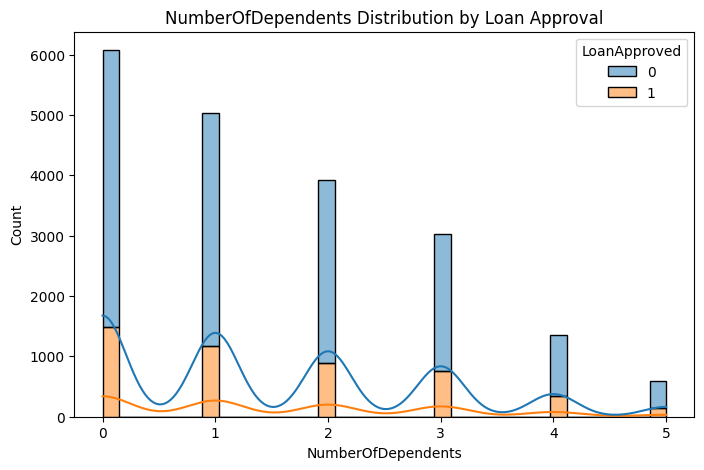

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="NumberOfDependents", hue="LoanApproved", kde=True, multiple='stack')
plt.title("NumberOfDependents Distribution by Loan Approval")
plt.show()

**feature engineering on application date feature**

In [ ]:
df["year"]=pd.to_datetime(df["ApplicationDate"]).dt.year
df["month"]=pd.to_datetime(df["ApplicationDate"]).dt.month
df.drop("ApplicationDate",axis=1,inplace=True)
df.drop("RiskScore",axis=1,inplace=True)

**pre processing encoding the categorical data to numeric data**

In [ ]:
df.select_dtypes(include="object").columns

Index(['EmploymentStatus', 'EducationLevel', 'MaritalStatus',
       'HomeOwnershipStatus', 'LoanPurpose'],
      dtype='object')

In [ ]:
Le=LabelEncoder()
df["EmploymentStatus"]=Le.fit_transform(df["EmploymentStatus"])
df["EducationLevel"]=Le.fit_transform(df["EducationLevel"])
df["MaritalStatus"]=Le.fit_transform(df["MaritalStatus"])
df["HomeOwnershipStatus"]=Le.fit_transform(df["HomeOwnershipStatus"])
df["LoanPurpose"]=Le.fit_transform(df["LoanPurpose"])




In [ ]:
df.head(5)

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,year,month
0,45,10.595359,617,0,4,22,9.484405,6.928203,1,2,...,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,2018,1
1,38,10.589358,628,0,0,15,10.167619,6.928203,2,1,...,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,2018,1
2,47,10.614597,570,0,1,26,9.777244,6.000000,1,2,...,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,2018,1
3,58,11.143093,545,0,3,34,10.542680,9.797959,2,1,...,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,2018,1
4,37,11.545054,594,0,0,17,9.125327,6.000000,1,1,...,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,2018,1


**after breakup session we have to train and split the data into two parts one part go to train training and second one is for test**

In [ ]:
x=df.drop("LoanApproved",axis=1)
y=df["LoanApproved"]
x

,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,year,month
0,45,10.595359,617,0,4,22,9.484405,6.928203,1,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,2018,1
1,38,10.589358,628,0,0,15,10.167619,6.928203,2,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,2018,1
2,47,10.614597,570,0,1,26,9.777244,6.000000,1,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,2018,1
3,58,11.143093,545,0,3,34,10.542680,9.797959,2,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,2018,1
4,37,11.545054,594,0,0,17,9.125327,6.000000,1,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,2018,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,44,10.314968,587,0,3,19,10.107326,6.000000,1,3,...,2515.000000,0.826217,1,55327,0.216021,0.195574,905.767712,0.627741,2072,9
19996,56,10.804604,567,0,0,33,10.158866,6.000000,1,5,...,4103.833333,0.816618,3,64002,0.227318,0.199168,958.395633,0.334418,2072,9
19997,44,10.798738,645,0,1,20,10.519592,8.485281,1,3,...,4079.833333,0.887216,3,103663,0.229533,0.226766,945.427454,0.357227,2072,10
19998,60,10.621961,560,0,3,36,9.599744,8.485281,1,3,...,3418.750000,0.843787,5,10600,0.249760,0.264873,411.168284,0.408678,2072,10


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)

(16000, 35)
(4000, 35)


**Featurescaling of x_x_train x_x_test**

In [ ]:
scaler=StandardScaler()
x_train2=scaler.fit_transform(x_train)
x_tesr2=scaler.transform(x_test)


** building multiple models and choose the best model with accuracy and best matrix**

In [ ]:
df.info().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  float64
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  int64  
 4   EducationLevel              20000 non-null  int64  
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  float64
 7   LoanDuration                20000 non-null  float64
 8   MaritalStatus               20000 non-null  int64  
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  int64  
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

AttributeError: 'NoneType' object has no attribute 'sum'

In [ ]:
lr=LogisticRegression(max_iter=100,random_state=42)
lr.fit(x_train2,y_train)
y_pred=lr.predict(x_tesr2)
y_prob=lr.predict_proba(x_tesr2)[:,1]
print("accuracy",accuracy_score(y_test,y_pred))
print("precision",precision_score(y_test,y_pred))
print("recall",recall_score(y_test,y_pred))
print("confusion matrix",confusion_matrix(y_test,y_pred))
print("ft_score",f1_score(y_test,y_pred))

In [ ]:
print(x.shape)
print(y.shape)

In [ ]:
y_prob = lr.predict_proba(x_tesr2)[:,1]

plt.figure(figsize=(8,4))
plt.scatter(y_prob, y_test, alpha=0.3)

plt.axvline(x=0.5, color='red', linestyle='--')

plt.xlabel("Predicted Probability")
plt.ylabel("Loan Approved (0/1)")
plt.title("Logistic Regression Predictions")
plt.show()

In [ ]:
from scipy.special import expit
sorted_idx = np.argsort(y_prob)
y_prob_sorted = y_prob[sorted_idx]
y_test_sorted = np.array(y_test)[sorted_idx]

plt.figure(figsize=(8,4))

plt.scatter(y_prob, y_test, alpha=0.3, label='Actual')

x_range = np.linspace(0, 1, 300)
z=(x_range-0.5)*12
sigmoid=expit(z)
plt.plot(x_range, sigmoid, color='green', linewidth=2, label='Sigmoid Curve')
plt.axvline(x=0.5, color='red', linestyle='--', label='Threshold=0.5')
plt.xlabel("Predicted Probability")
plt.ylabel("Loan Approved (0/1)")
plt.title("Logistic Regression Predictions with Curve")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

** KNeighborsClassification model building**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=6)
knn.fit(x_train2,y_train)
y_pred2=knn.predict(x_tesr2)
y_prob2=knn.predict_proba(x_tesr2)[:,1]
print("precision",precision_score(y_test,y_pred2))
print("recall",recall_score(y_test,y_pred2))
print("confusion matrix",confusion_matrix(y_test,y_pred2))
print("ft_score",f1_score(y_test,y_pred2))





In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob2)

# Plot
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob2):.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob2))


** decision tree classifier model building**

In [ ]:
dt=DecisionTreeClassifier(max_depth=5,min_samples_split=5,criterion="gini")
dt.fit(x_train,y_train)
y_pred3=dt.predict(x_test)
y_prob3=dt.predict_proba(x_test)[:,1]
print("accuarcy of DecisionTree",accuracy_score(y_test,y_pred3))
print("precision score",precision_score(y_test,y_pred3))
print("recall",recall_score(y_test,y_pred3))
print("confusion matrix",confusion_matrix(y_test,y_pred3))
print("ft_score",f1_score(y_test,y_pred3))




In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob3)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob3):.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Decisiontree ROC Curve")
plt.legend()
plt.show()

print("ROC-AUC Score")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=100,max_depth=10,criterion="gini")
rf.fit(x_train,y_train)
y_pred5=rf.predict(x_test)
y_prob5=rf.predict_proba(x_test)[:,1]
print("accuarcy of Random forest",accuracy_score(y_test,y_pred5))
print("precision score",precision_score(y_test,y_pred5))
print("recall",recall_score(y_test,y_pred5))
print("confusiom matrix",confusion_matrix(y_test,y_pred5))
print("f1_score",f1_score(y_test,y_pred5))


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob5)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob5):.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random forest ROC Curve")
plt.legend()

Xgboost classifier for model building**

In [ ]:
from xgboost import XGBClassifier
xgb=XGBClassifier(n_estimators=400,learning_rate=0.1,max_depth=4,random_state=42)
xgb.fit(x_train,y_train)
y_pred4=xgb.predict(x_test)
y_prob4=xgb.predict_proba(x_test)[:,1]
print("accuarcy of XGBoost",accuracy_score(y_test,y_pred4))
print("precision score",precision_score(y_test,y_pred4))
print("recall",recall_score(y_test,y_pred4))
print("confusiom matrix",confusion_matrix(y_test,y_pred4))
print("f1_score",f1_score(y_test,y_pred4))


In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob4)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob4):.3f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("XGBoost ROC Curve")
plt.legend()
plt.show()


In [ ]:
import pickle

with open("model.pkl", "wb") as file:
    pickle.dump(xgb, file)

    print("Model saved successfully!")

In [ ]:
import streamlit as st
import pickle
import numpy as np

# Load saved model
with open("model.pkl", "rb") as file:
    model = pickle.load(file)

    st.title("Loan Approval Prediction App")

    # Replace these with your actual features
    age = st.number_input("Age", min_value=18, max_value=100)
    income = st.number_input("Income", min_value=0)
    credit_score = st.number_input("Credit Score", min_value=0)

    if st.button("Predict"):

        input_data = np.array([[age, income, credit_score]])

        prediction = model.predict(input_data)

        if prediction[0] == 1:
                        st.success("Loan Approved")
        else:
            st.error("Loan Rejected")

2026-06-14 13:36:19.893 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 13:36:19.894 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 13:36:19.897 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 13:36:19.898 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 13:36:19.900 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 13:36:19.901 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 13:36:19.902 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-14 13:36:19.904 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

In [ ]:
import streamlit as st
import numpy as np
import pandas as pd
import sklearn
import xgboost as xgb

In [ ]:
st
np
pd
sklearn
xgb

<module 'xgboost' from '/usr/local/lib/python3.12/dist-packages/xgboost/__init__.py'>

In [ ]:
from google.colab import files
files.download("model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
app_code = """
import streamlit as st
import pickle

st.title("Loan Approval Prediction")

with open('model.pkl', 'rb') as file:
    model = pickle.load(file)

    st.write("Model Loaded Successfully")
    """

with open("app.py", "w") as f:
    f.write(app_code)
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
requirements = """
streamlit
numpy
pandas
scikit-learn
xgboost
"""

with open("requirements.txt", "w") as f:
    f.write(requirements)

from google.colab import files
files.download("requirements.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>